# Instalação e Importação das Bibliotecas

In [1]:
# Instale as bibliotecas caso não tenha:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# Geração do Dataset Simulado

In [2]:
# Criando um dataset simulado de interações com o TotemFlexmedia
np.random.seed(42)
n_amostras = 500

idades = np.random.randint(12, 75, n_amostras)
idiomas = np.random.choice(['PT-BR', 'EN-US', 'ES-ES'], n_amostras, p=[0.7, 0.2, 0.1])
periodos_dia = np.random.choice(['Manha', 'Tarde', 'Noite'], n_amostras, p=[0.3, 0.5, 0.2])
tempo_interacao = np.random.randint(15, 120, n_amostras) # tempo em segundos

# Lógica simulada para a atração (Target)
atracoes = []
for i in range(n_amostras):
    if idades[i] < 25 and idiomas[i] == 'PT-BR':
        atracoes.append('Exposição Interativa VR')
    elif idades[i] >= 50 or periodos_dia[i] == 'Manha':
        atracoes.append('História e Acervo Clássico')
    elif idiomas[i] != 'PT-BR':
        atracoes.append('Tour Internacional Guiado')
    else:
        atracoes.append('Mapa Geral e Serviços')

# Montando o DataFrame
df_totem = pd.DataFrame({
    'Idade': idades,
    'Idioma': idiomas,
    'Periodo': periodos_dia,
    'Tempo_Segundos': tempo_interacao,
    'Recomendacao_Atracao': atracoes
})

print("Amostra dos Dados Simulados:")
display(df_totem.head())

Amostra dos Dados Simulados:


,Idade,Idioma,Periodo,Tempo_Segundos,Recomendacao_Atracao
0,50,EN-US,Tarde,62,História e Acervo Clássico
1,63,ES-ES,Tarde,74,História e Acervo Clássico
2,40,PT-BR,Tarde,77,Mapa Geral e Serviços
3,26,PT-BR,Noite,100,Mapa Geral e Serviços
4,54,PT-BR,Tarde,16,História e Acervo Clássico


# Gráficos Analíticos

/tmp/ipykernel_830/1734016501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_totem, x='Idioma', palette='viridis')
/tmp/ipykernel_830/1734016501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_totem, y='Recomendacao_Atracao', palette='mako', order=df_totem['Recomendacao_Atracao'].value_counts().index)
/tmp/ipykernel_830/1734016501.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_totem, x='Periodo', y='Tempo_Segundos', palette='magma')


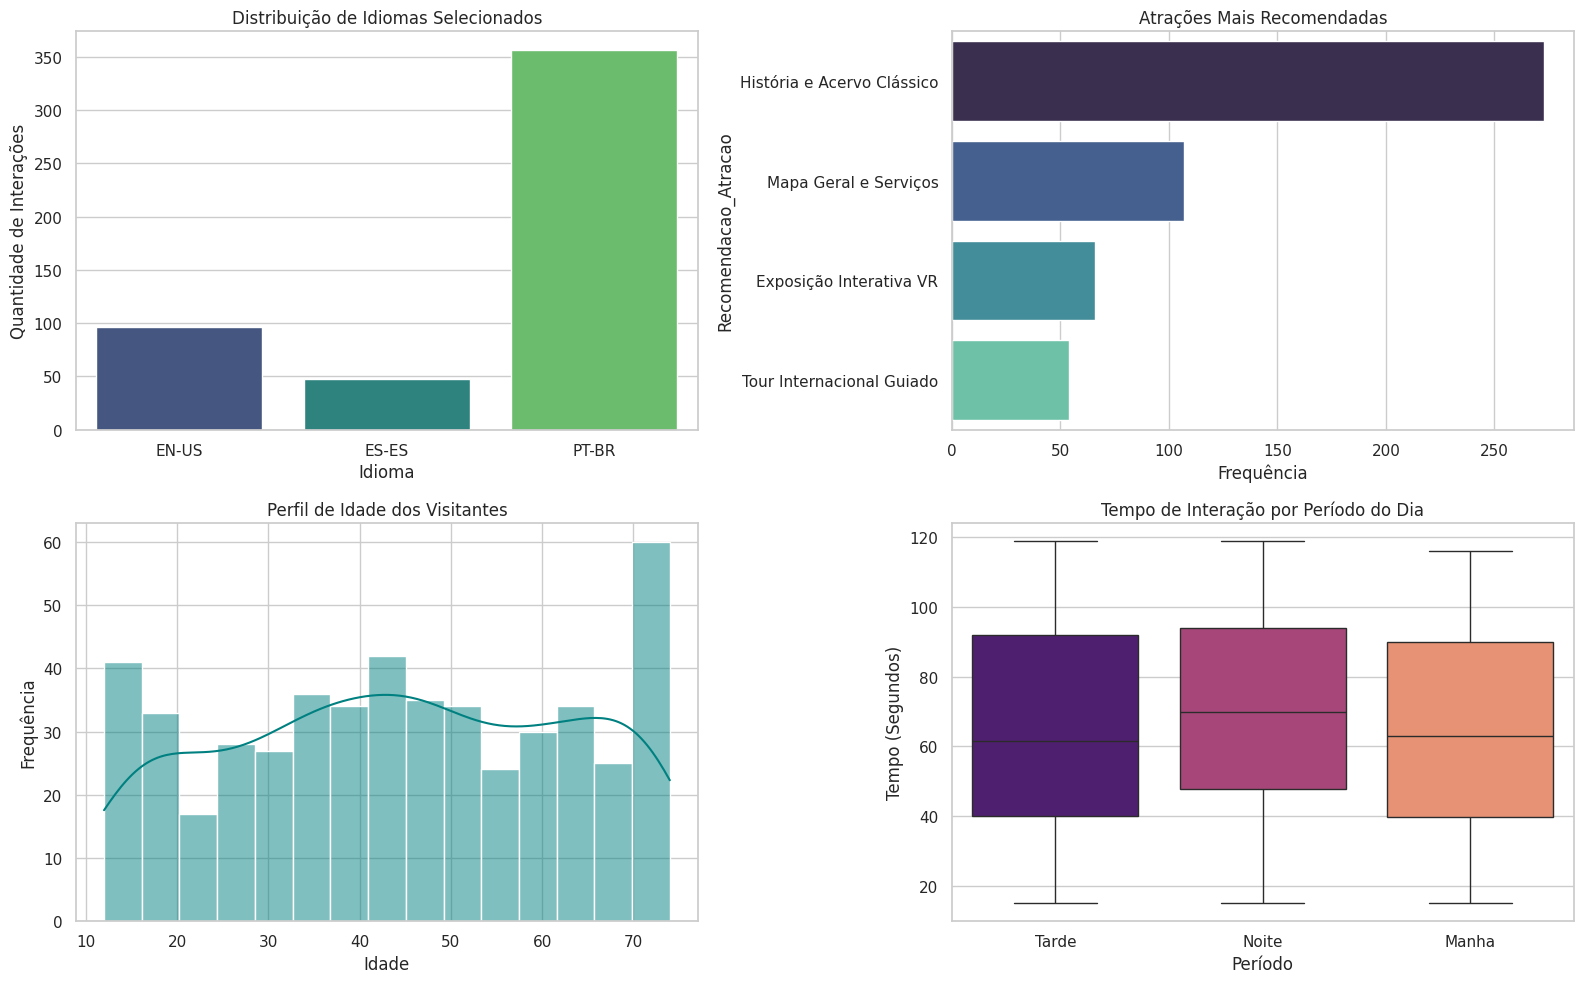

In [3]:
plt.figure(figsize=(16, 10))

# 1. Gráfico de Frequência de Idiomas
plt.subplot(2, 2, 1)
sns.countplot(data=df_totem, x='Idioma', palette='viridis')
plt.title('Distribuição de Idiomas Selecionados')
plt.ylabel('Quantidade de Interações')

# 2. Distribuição das Atrações Recomendadas
plt.subplot(2, 2, 2)
sns.countplot(data=df_totem, y='Recomendacao_Atracao', palette='mako', order=df_totem['Recomendacao_Atracao'].value_counts().index)
plt.title('Atrações Mais Recomendadas')
plt.xlabel('Frequência')

# 3. Distribuição de Idades dos Visitantes
plt.subplot(2, 2, 3)
sns.histplot(df_totem['Idade'], bins=15, kde=True, color='teal')
plt.title('Perfil de Idade dos Visitantes')
plt.xlabel('Idade')
plt.ylabel('Frequência')

# 4. Tempo de Interação por Período
plt.subplot(2, 2, 4)
sns.boxplot(data=df_totem, x='Periodo', y='Tempo_Segundos', palette='magma')
plt.title('Tempo de Interação por Período do Dia')
plt.xlabel('Período')
plt.ylabel('Tempo (Segundos)')

plt.tight_layout()
plt.show()

# Preparação dos Dados (Pré-processamento)

In [4]:
# Cópia do dataframe para não alterar o original
df_model = df_totem.copy()

# Transformando variáveis categóricas em numéricas (Label Encoding)
encoder_idioma = LabelEncoder()
df_model['Idioma'] = encoder_idioma.fit_transform(df_model['Idioma'])

encoder_periodo = LabelEncoder()
df_model['Periodo'] = encoder_periodo.fit_transform(df_model['Periodo'])

# Separando as Features (X) do Target (y)
X = df_model.drop('Recomendacao_Atracao', axis=1)
y = df_model['Recomendacao_Atracao']

# Divisão em Treino (80%) e Teste (20%) - Exigência do edital
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de Treino: 400 amostras
Tamanho do conjunto de Teste: 100 amostras


# Treinamento e Avaliação do Modelo de IA

--- RESULTADOS DO MODELO ---
Acurácia Geral do Modelo: 100.00%

Relatório de Classificação Detalhado:
                            precision    recall  f1-score   support

   Exposição Interativa VR       1.00      1.00      1.00        16
História e Acervo Clássico       1.00      1.00      1.00        57
     Mapa Geral e Serviços       1.00      1.00      1.00        21
 Tour Internacional Guiado       1.00      1.00      1.00         6

                  accuracy                           1.00       100
                 macro avg       1.00      1.00      1.00       100
              weighted avg       1.00      1.00      1.00       100



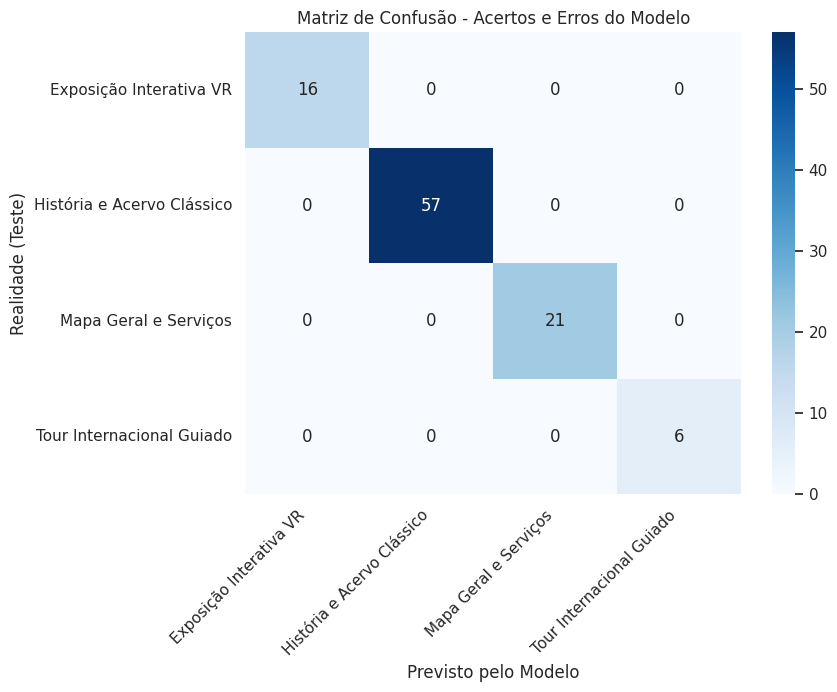

In [5]:
# Inicializando e treinando o modelo de Classificação (Random Forest)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Fazendo predições no conjunto de teste
y_pred = modelo_rf.predict(X_test)

# Métricas de Avaliação
acuracia = accuracy_score(y_test, y_pred)
print(f"--- RESULTADOS DO MODELO ---")
print(f"Acurácia Geral do Modelo: {acuracia * 100:.2f}%\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão Visual
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_)
plt.title('Matriz de Confusão - Acertos e Erros do Modelo')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Realidade (Teste)')
plt.xticks(rotation=45, ha='right')
plt.show()